# <span style="font-size:16pt; font-weight:bold;">Notebook 23: Comprehensive DL Architecture Analysis</span>


## <span style="font-size:14pt; font-weight:bold;">1. Setup</span>


In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path; import warnings; warnings.filterwarnings('ignore')
REPO=Path.home()/'projects'/'music-prediction'
IMGS=REPO/'results/figures/thesis'; ANALYSIS=REPO/'results/analysis'; DLM=REPO/'results/dl_metrics'
IMGS.mkdir(parents=True,exist_ok=True); ANALYSIS.mkdir(parents=True,exist_ok=True)
TARGETS=['valence','energy','danceability','popularity']
AO=['FlatAllMLP','MultiModalFusionMLP','TaskGatedFusionMLP','AttentionTaskGatedFusionMLP','TaskGatedFusionMLP_FeatEng']
AC={'FlatAllMLP':'#4C72B0','MultiModalFusionMLP':'#DD8452','TaskGatedFusionMLP':'#55A868','AttentionTaskGatedFusionMLP':'#C44E52','TaskGatedFusionMLP_FeatEng':'#7A68A6'}
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','font.size':12,'axes.labelsize':14,'axes.titlesize':14})
print('Setup complete.')


Setup complete.


In [6]:
DT=DLM/'final_dl_test_20260601_212018.csv'; DTT=DLM/'final_dl_test_20260601_224941.csv'
dfs={}
for k,p in [('test_def',DT),('test_tun',DTT)]:
    if p.exists(): dfs[k]=pd.read_csv(p); dfs[k]['src']=k; print(f'Loaded {p.name}: {len(dfs[k])} rows')
    else: print(f'{p.name} not found')
dl=pd.concat(dfs.values(),ignore_index=True) if dfs else None; print('DL data loaded.')


Loaded final_dl_test_20260601_212018.csv: 20 rows
Loaded final_dl_test_20260601_224941.csv: 4 rows
DL data loaded.


## <span style="font-size:14pt; font-weight:bold;">2. Architecture Descriptions</span>


In [7]:
ai=pd.DataFrame([
    {'Arch':'FlatAllMLP','Desc':'Simple neural baseline','Encoders':'None','Fusion':'None'},
    {'Arch':'MultiModalFusionMLP','Desc':'Per-modality encoders','Encoders':'MLPs','Fusion':'Concat+Dense'},
    {'Arch':'TaskGatedFusionMLP','Desc':'Per-target gates','Encoders':'MLPs','Fusion':'Gated per target'},
    {'Arch':'AttentionTaskGatedFusionMLP','Desc':'Cross-modal attention','Encoders':'MLPs','Fusion':'Attn+Gated'},
    {'Arch':'TaskGatedFusionMLP_FeatEng','Desc':'Gated+FeatEng','Encoders':'MLPs','Fusion':'Gated+FeatEng'},
]); print(ai.to_string(index=False))


                       Arch                   Desc Encoders           Fusion
                 FlatAllMLP Simple neural baseline     None             None
        MultiModalFusionMLP  Per-modality encoders     MLPs     Concat+Dense
         TaskGatedFusionMLP       Per-target gates     MLPs Gated per target
AttentionTaskGatedFusionMLP  Cross-modal attention     MLPs       Attn+Gated
 TaskGatedFusionMLP_FeatEng          Gated+FeatEng     MLPs    Gated+FeatEng


## <span style="font-size:14pt; font-weight:bold;">3. Architecture Progression</span>


DL R2 (Default)
target                       danceability  energy  popularity  valence     Avg
model                                                                         
FlatAllMLP                         0.7223  0.8891      0.0910   0.7023  0.6012
MultiModalFusionMLP                0.7375  0.8861      0.0822   0.7056  0.6028
TaskGatedFusionMLP                 0.7755  0.9025      0.0765   0.7253  0.6199
AttentionTaskGatedFusionMLP        0.7699  0.9014      0.0915   0.7220  0.6212
TaskGatedFusionMLP_FeatEng         0.7766  0.9092      0.0606   0.7156  0.6155


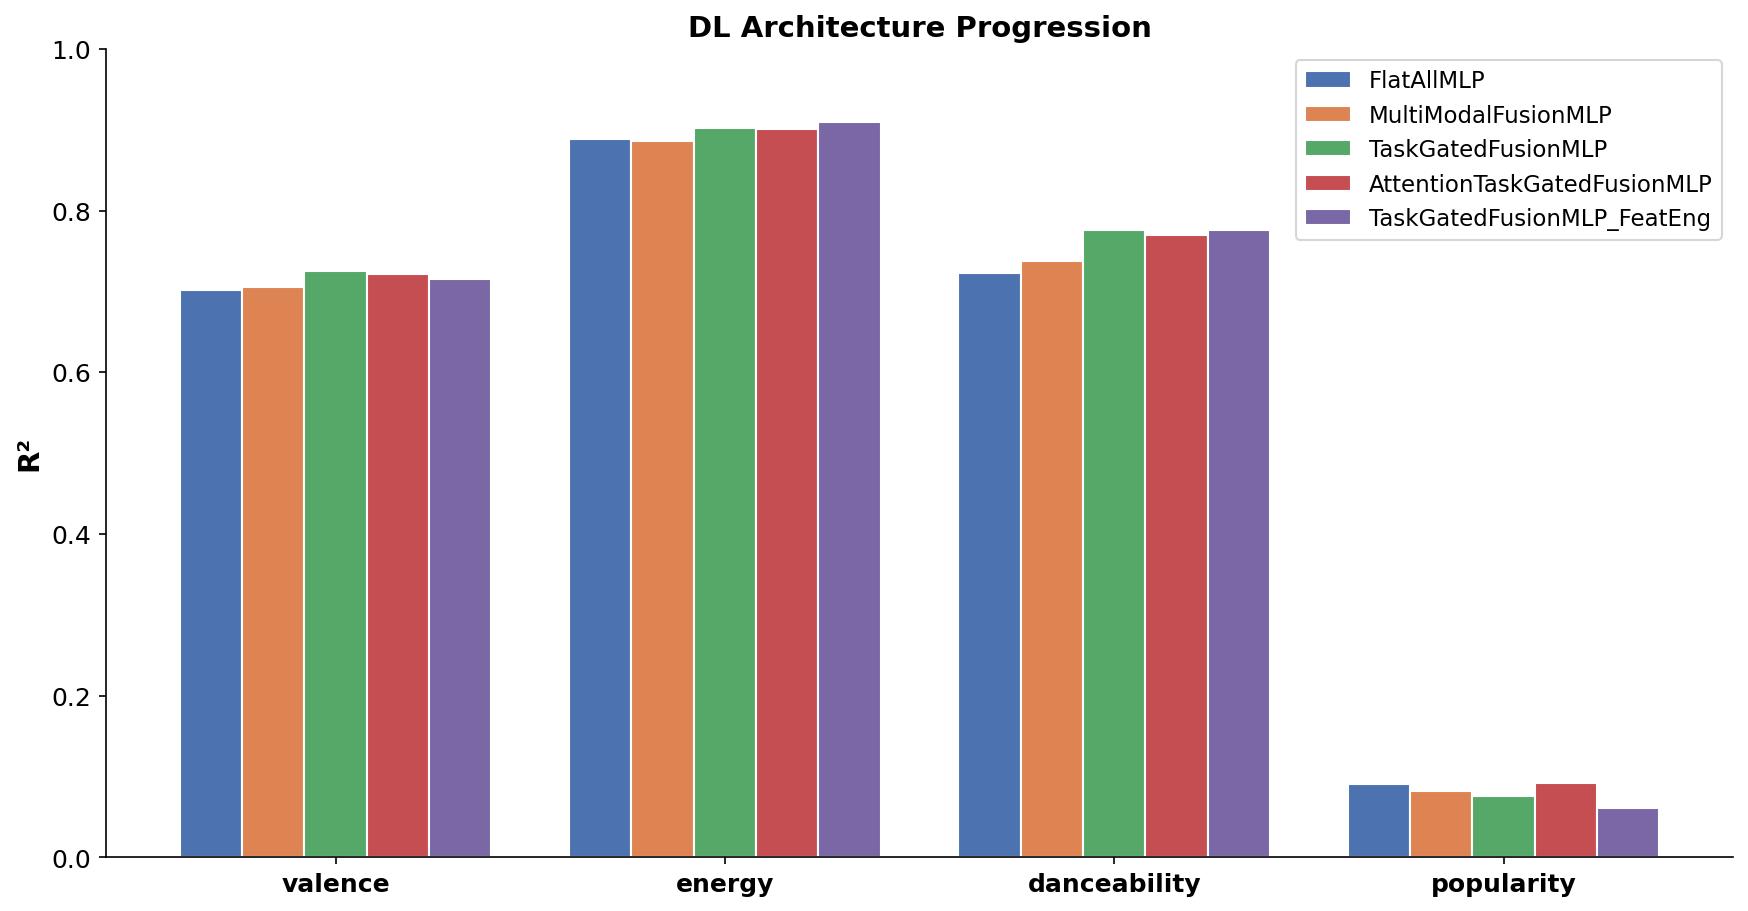

In [11]:
td=dl[dl['src']=='test_def']
ap=td.pivot_table(index='model',columns='target',values='r2',aggfunc='first')
ap=ap.reindex([a for a in AO if a in ap.index]); ap['Avg']=ap.mean(axis=1)
print('DL R2 (Default)'); print('='*60); print(ap.round(4).to_string())
fig,ax=plt.subplots(figsize=(14,7)); x=np.arange(len(TARGETS))
n=len([a for a in AO if a in ap.index]); w=0.8/n
for i,a in enumerate([a for a in AO if a in ap.index]):
    vals=[ap.loc[a,t] for t in TARGETS]; offset=(i-n/2+0.5)*w
    ax.bar(x+offset,vals,w,label=a,color=AC.get(a),edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(TARGETS,fontsize=12,fontweight='bold')
ax.set_ylabel('R²',fontsize=14,fontweight='bold'); ax.set_title('DL Architecture Progression',fontsize=14,fontweight='bold')
ax.legend(fontsize=11,loc='upper right'); ax.set_ylim(0,1); sns.despine()
fig.savefig(IMGS/'23_dl_progression.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">4. Default vs Tuned AttentionDL</span>


In [9]:
tt=dl[dl['src']=='test_tun']
ad=td[td['model']=='AttentionTaskGatedFusionMLP']; at=tt[tt['model']=='AttentionTaskGatedFusionMLP']
if len(ad)>0 and len(at)>0:
    cp=ad.merge(at,on='target',suffixes=('_def','_tun'))
    print('AttentionDL: Default vs Tuned'); print('-'*50)
    for _,r in cp.iterrows(): d=r['r2_tun']-r['r2_def']; print(f'  {r["target"]}: {r["r2_def"]:.4f} -> {r["r2_tun"]:.4f} (d={d:+.4f})')


AttentionDL: Default vs Tuned
--------------------------------------------------
  valence: 0.7220 -> 0.7214 (d=-0.0006)
  energy: 0.9014 -> 0.9050 (d=+0.0036)
  danceability: 0.7699 -> 0.7700 (d=+0.0002)
  popularity: 0.0915 -> 0.1092 (d=+0.0177)


## <span style="font-size:14pt; font-weight:bold;">5. Key Findings</span>


In [10]:
print('='*70); print('NOTEBOOK 23: KEY FINDINGS'); print('='*70)
for a in ap.index: print(f'  {a}: avg R2 = {ap.loc[a,"Avg"]:.4f}')
ap.round(6).to_csv(ANALYSIS/'23_dl_summary.csv',index=False); print('Notebook 23 complete.')


NOTEBOOK 23: KEY FINDINGS
  FlatAllMLP: avg R2 = 0.6012
  MultiModalFusionMLP: avg R2 = 0.6028
  TaskGatedFusionMLP: avg R2 = 0.6199
  AttentionTaskGatedFusionMLP: avg R2 = 0.6212
  TaskGatedFusionMLP_FeatEng: avg R2 = 0.6155
Notebook 23 complete.
